In [1]:
from astropy import units as u

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from snewpy.models.ccsn import Nakazato_2013

from asteria.simulation import Simulation
from asteria import set_rcparams
from asteria import interactions

set_rcparams(verbose=False)
%matplotlib inline

In [2]:
# Model used for SN Firedrills in 2023
param  = {
    "progenitor_mass": 13 * u.Msun,
    "revival_time": 300 * u.ms,
    "metallicity": 0.02,
    "eos": "shen"
}
model = {
    "name": "Nakazato_2013",
    "param": param
}
Nakazato_2013(**param)

**Nakazato_2013 Model**: nakazato-shen-z0.02-t_rev300ms-s13.0.fits

|Parameter|Value|
|:--------|:----:|
|Progenitor mass | $13$ $\mathrm{M_{\odot}}$|
|Revival time | $300$ $\mathrm{ms}$|
|Metallicity | 0.02 |
|EOS | shen |

In [3]:
sim = Simulation(model=model,
                 distance=10 * u.kpc,
                 Emin=0 * u.MeV, Emax=100 * u.MeV, dE=1 * u.MeV,
                 tmin=-10 * u.s, tmax= 30 * u.s, dt=1 * u.ms, 
                )
sim.run()

In [4]:
# Utility for printing results neatly, assumes, sample_significance argument only_highest=False
base_bin_size = 0.5 * u.s
bin_sizes = [0.5, 1.5, 4, 10] * u.s

def print_sample(s, *, end="\n"):
    if isinstance(s[0], float):
        s = [s,]
        
    base_fmt = "{{0:{fmt}}} | {{1:{fmt}}} | {{2:{fmt}}} | {{3:{fmt}}}"
    row_fmt = base_fmt.format(fmt=">7.2f")
    hdr_fmt = base_fmt.format(fmt="^7s")
    
    hdr = hdr_fmt.format(*[str(b) for b in bin_sizes])
    div = len(hdr) * "-"
    rows = [row_fmt.format(*row) for row in s]
    table = "\n".join([hdr, div, *rows])

    print(table, end=end)

In [5]:
# Estimated background characteristics for run 127138 (used for FD, obtained with PySNDAQ)
sim.detector.set_i3_background(mu = 289.436, sig = 20.723)
sim.detector.set_dc_background(mu = 377.480, sig = 23.040)

xi = sim.trigger_significance(base_bin_size, binnings=bin_sizes)
print_sample(xi, end=3*"\n")

sample = sim.sample_significance(10, dt=base_bin_size, binnings=bin_sizes, only_highest=False)
print_sample(sample)

 0.5 s  |  1.5 s  |  4.0 s  | 10.0 s 
-------------------------------------
 249.04 |  158.62 |  106.51 |   73.35


 0.5 s  |  1.5 s  |  4.0 s  | 10.0 s 
-------------------------------------
 224.31 |  154.11 |  104.97 |   72.80
 205.02 |  153.86 |  104.21 |   74.26
 134.53 |  153.57 |  105.26 |   74.20
 154.36 |  156.19 |  110.91 |   76.77
 227.09 |  152.64 |  104.51 |   72.66
 186.55 |  161.08 |  110.88 |   77.20
 240.87 |  156.16 |  107.30 |   74.67
 246.62 |  160.03 |  108.27 |   75.97
 198.16 |  152.33 |  106.12 |   73.69
 239.38 |  156.19 |  107.08 |   74.76


In [6]:
sample = sim.sample_significance(100, dt=base_bin_size, binnings=bin_sizes, only_highest=True)
print(f"xi = {f'{sample.mean():>.2f} +- {sample.std():<.2f}'} (sample)")
print(f"xi = 193.36 +- 13.91 (arXiv:2308.01843, 2023)")
print(f"xi_FD = 204.15")

xi = 203.72 +- 33.53 (sample)
xi = 193.36 +- 13.91 (arXiv:2308.01843, 2023)
xi_FD = 204.15


See [https://arxiv.org/abs/2308.01843](arXiv:2308.01843) for more information on Firedrill (FD) expectation. Note, ASTERIA, SNEWPY, and SNDAQ have received multiple updates since this proceeding, and the parameters of the FD simulation may not be perfectly matched by this notebook. 

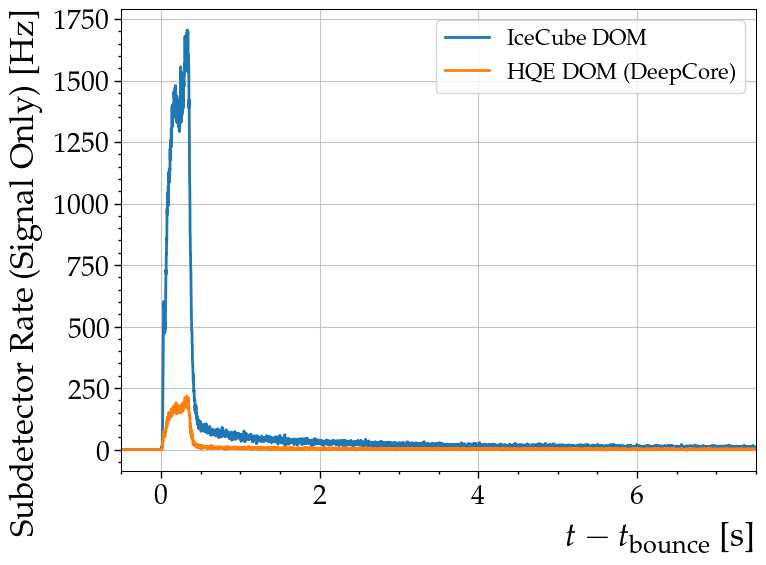

In [7]:
dt = 2 * u.ms
t, hits_i3 = sim.detector_hits(subdetector='i3', dt=dt)
t, hits_dc = sim.detector_hits(subdetector='dc', dt=dt)

fig, ax = plt.subplots(1,1, figsize=(8,6), tight_layout=True)
ax.plot(t, hits_i3, label='IceCube DOM')
ax.plot(t, hits_dc, label='HQE DOM (DeepCore)')
ax.legend()
ax.set(xlabel=r'$t-t_\mathrm{bounce}$ [s]',
       ylabel=f'Subdetector Rate (Signal Only) [Hz]',
       xlim=(-0.5, 7.5));

In [8]:
sim = Simulation(model=model,
                 distance=10 * u.kpc,
                 Emin=0 * u.MeV, Emax=100 * u.MeV, dE=1 * u.MeV,
                 tmin=-10 * u.s, tmax= 30 * u.s, dt=1 * u.ms,
                 detector_scope="Gen2")
sim.run()

In [9]:
xi = sim.trigger_significance(base_bin_size, binnings=bin_sizes)
print_sample(xi, end=3*"\n")

sample = sim.sample_significance(10, dt=base_bin_size, binnings=bin_sizes, only_highest=False)
print_sample(sample)

 0.5 s  |  1.5 s  |  4.0 s  | 10.0 s 
-------------------------------------
 307.45 |  194.67 |  128.60 |   90.38


 0.5 s  |  1.5 s  |  4.0 s  | 10.0 s 
-------------------------------------
 294.30 |  195.09 |  134.12 |   93.53
 203.30 |  189.64 |  130.66 |   90.10
 272.77 |  197.89 |  136.05 |   94.94
 300.28 |  194.29 |  134.22 |   94.16
 274.23 |  185.99 |  128.29 |   90.37
 292.86 |  191.17 |  132.13 |   91.51
 254.96 |  196.15 |  134.86 |   94.96
 301.43 |  196.06 |  134.53 |   93.50
 173.08 |  192.88 |  134.04 |   92.99
 160.41 |  194.43 |  132.24 |   91.88


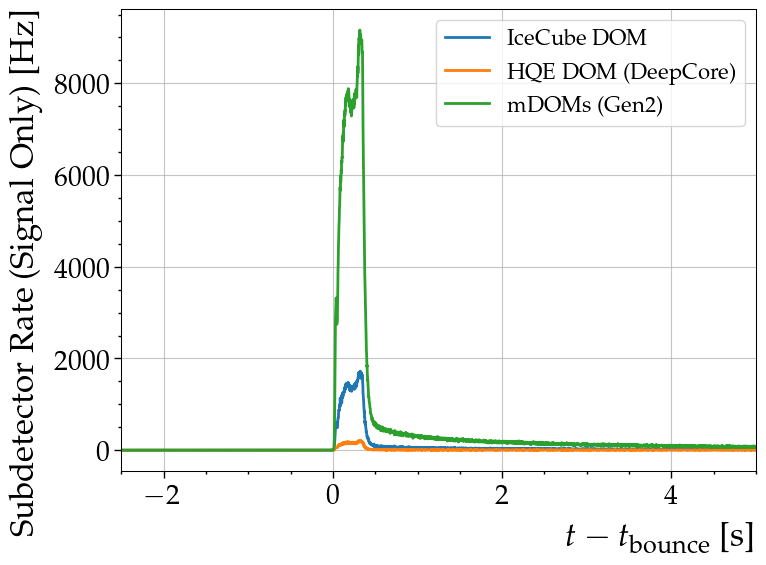

In [10]:
dt = 2 * u.ms
t, hits_i3 = sim.detector_hits(subdetector='i3', dt=dt)
t, hits_dc = sim.detector_hits(subdetector='dc', dt=dt)
t, hits_md = sim.detector_hits(subdetector='md', dt=dt)

fig, ax = plt.subplots(1,1, figsize=(8,6), tight_layout=True)
ax.plot(t, hits_i3, label='IceCube DOM')
ax.plot(t, hits_dc, label='HQE DOM (DeepCore)')
ax.plot(t, hits_md, label='mDOMs (Gen2)')
ax.legend()
ax.set(xlabel=r'$t-t_\mathrm{bounce}$ [s]',
       ylabel=f'Subdetector Rate (Signal Only) [Hz]',
       xlim=(-2.5, 5));